In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/financial_transactions.csv")

In [8]:
df.head()

,Transaction_ID,Transaction_Date,Company_Code,Cost_Center,Profit_Center,Account_Category,Transaction_Type,Amount,Budget,Payment_Status,Description,Quantity,Department,Currency,Invoice_ID,Vendor_ID,Tax_Amount,Profit,Approval_Status,Anomaly_Indicator
0,TX005450,01-17-2024,C003,CC107,PC206,Procurement,Expense,660134.88,870600.30,Pending,Raw material procurement,653.0,Procurement,INR,INV-2024-04285,NaN,115121.44,NaN,Approved,0
1,TX000061,01-21-2021,C001,CC111,PC202,Marketing,Expense,226317.84,255507.62,Paid,Marketing campaign,1.0,Sales,INR,INV-2021-00045,V040,42898.57,NaN,Approved,0
2,TX007730,02-10-2025,C002,CC105,PC206,Marketing,Expense,381300.39,427732.69,Partially Paid,Trade show sponsorship,1.0,Marketing,INR,INV-2025-06066,V035,70826.38,NaN,Approved,0
3,TX003695,02-14-2023,C002,CC112,PC204,Procurement,Expense,352712.21,360120.03,Partially Paid,Software license purchase,319.0,Operations,INR,INV-2023-02901,V001,62394.66,NaN,Approved,0
4,TX001800,02-25-2022,C005,CC104,PC206,Sales,Revenue,599713.69,603576.07,Paid,Product sales revenue,450.0,Sales,INR,INV-2022-01433,NaN,109719.59,164961.87,Pending,0


In [10]:
df.shape

(9802, 20)

In [11]:
df.columns

Index(['Transaction_ID', 'Transaction_Date', 'Company_Code', 'Cost_Center',
       'Profit_Center', 'Account_Category', 'Transaction_Type', 'Amount',
       'Budget', 'Payment_Status', 'Description', 'Quantity', 'Department',
       'Currency', 'Invoice_ID', 'Vendor_ID', 'Tax_Amount', 'Profit',
       'Approval_Status', 'Anomaly_Indicator'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9802 entries, 0 to 9801
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     9802 non-null   object 
 1   Transaction_Date   9802 non-null   object 
 2   Company_Code       9802 non-null   object 
 3   Cost_Center        9802 non-null   object 
 4   Profit_Center      9802 non-null   object 
 5   Account_Category   9802 non-null   object 
 6   Transaction_Type   9802 non-null   object 
 7   Amount             9802 non-null   float64
 8   Budget             9802 non-null   float64
 9   Payment_Status     9802 non-null   object 
 10  Description        9802 non-null   object 
 11  Quantity           9746 non-null   float64
 12  Department         9802 non-null   object 
 13  Currency           9802 non-null   object 
 14  Invoice_ID         7649 non-null   object 
 15  Vendor_ID          5107 non-null   object 
 16  Tax_Amount         9802 

In [13]:
df.isnull().sum()

Transaction_ID          0
Transaction_Date        0
Company_Code            0
Cost_Center             0
Profit_Center           0
Account_Category        0
Transaction_Type        0
Amount                  0
Budget                  0
Payment_Status          0
Description             0
Quantity               56
Department              0
Currency                0
Invoice_ID           2153
Vendor_ID            4695
Tax_Amount              0
Profit               8255
Approval_Status         0
Anomaly_Indicator       0
dtype: int64

In [14]:
df.describe()

,Amount,Budget,Quantity,Tax_Amount,Profit,Anomaly_Indicator
count,9.802000e+03,9.802000e+03,9746.000000,9.802000e+03,1.547000e+03,9802.000000
mean,2.691135e+05,2.594845e+05,143.687564,3.818644e+04,1.862563e+05,0.019894
std,4.077968e+05,2.815241e+05,304.058634,5.237973e+04,1.262018e+05,0.139643
min,1.023910e+03,1.000590e+03,1.000000,0.000000e+00,8.773250e+03,0.000000
25%,5.801386e+04,5.859828e+04,1.000000,4.010652e+03,1.088826e+05,0.000000
50%,1.441003e+05,1.474760e+05,4.000000,1.265024e+04,1.653901e+05,0.000000
75%,3.646739e+05,3.712023e+05,145.000000,5.802213e+04,2.409608e+05,0.000000
max,1.063286e+07,2.365446e+06,5869.000000,1.140199e+06,2.479764e+06,1.000000


In [16]:
df["Transaction_Date"].min(), df["Transaction_Date"].max()

('01-01-2021', '31-12-2025')

In [17]:
df["Transaction_Date"].value_counts().sort_index().head(20)

Transaction_Date
01-01-2021     9
01-01-2022     1
01-01-2023     6
01-01-2024     5
01-01-2025    10
01-02-2021     4
01-02-2022     4
01-02-2023     4
01-02-2024    10
01-02-2025    10
01-03-2021     7
01-03-2022    10
01-03-2023    11
01-03-2024     5
01-03-2025     9
01-04-2021     9
01-04-2022     2
01-04-2023     6
01-04-2024     6
01-04-2025     7
Name: count, dtype: int64

In [18]:
df["Transaction_Type"].value_counts()

Transaction_Type
Expense    8255
Revenue    1547
Name: count, dtype: int64

In [19]:
df["Account_Category"].value_counts()

Account_Category
Sales              1537
Office Supplies    1463
Other              1339
Maintenance        1010
IT                  861
Travel              768
Procurement         722
Utilities           582
Marketing           580
Logistics           460
Salaries            422
SALES                10
maintenance          10
other                 8
Office_Supplies       6
I.T.                  6
Marketting            5
utilities             4
TRAVEL                4
salaries              4
logistics             1
Name: count, dtype: int64

In [20]:
df["Department"].value_counts()

Department
Sales                2750
Finance              1214
Operations           1204
IT                   1197
Marketing            1190
Administration       1097
Procurement           553
HR                    544
  Sales                 9
  Operations            9
  Marketing             8
  IT                    8
  Administration        7
  Finance               7
  HR                    5
Name: count, dtype: int64

In [21]:
df["Cost_Center"].nunique(), df["Profit_Center"].nunique()

(14, 7)

In [22]:
df["Company_Code"].value_counts()

Company_Code
C001     3177
C002     2730
C003     1966
C004     1337
C005      536
c001       18
c002       15
c003       14
c004        5
c005        4
Name: count, dtype: int64

In [23]:
df.groupby("Transaction_Type")["Amount"].agg(["count", "sum", "mean", "median"])

,count,sum,mean,median
Transaction_Type,,,,
Expense,8255,1.644467e+09,199208.564125,112355.24
Revenue,1547,9.933833e+08,642135.324855,559752.87


In [24]:
df["Payment_Status"].value_counts()

Payment_Status
Paid              6178
Pending           1529
Overdue           1083
Partially Paid    1012
Name: count, dtype: int64

In [25]:
df["Approval_Status"].value_counts()

Approval_Status
Approved        7984
Pending          910
Rejected         472
Under Review     436
Name: count, dtype: int64

In [26]:
df["Currency"].value_counts()

Currency
INR    9802
Name: count, dtype: int64

In [27]:
df.groupby("Transaction_Type")["Anomaly_Indicator"].sum()

Transaction_Type
Expense    167
Revenue     28
Name: Anomaly_Indicator, dtype: int64

In [28]:
df[["Amount", "Budget"]].corr()

,Amount,Budget
Amount,1.000000,0.693407
Budget,0.693407,1.000000


In [29]:
df.groupby("Transaction_Type")["Profit"].agg(["count", "mean", "sum"])

,count,mean,sum
Transaction_Type,,,
Expense,0,NaN,0.000000e+00
Revenue,1547,186256.336361,2.881386e+08


****Visual EDA 📊****

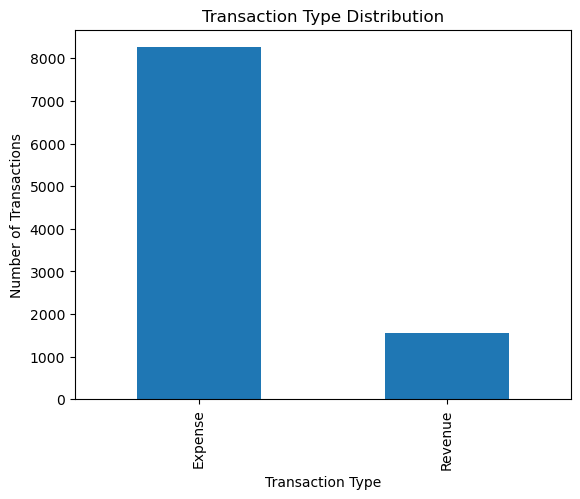

In [31]:
df["Transaction_Type"].value_counts().plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

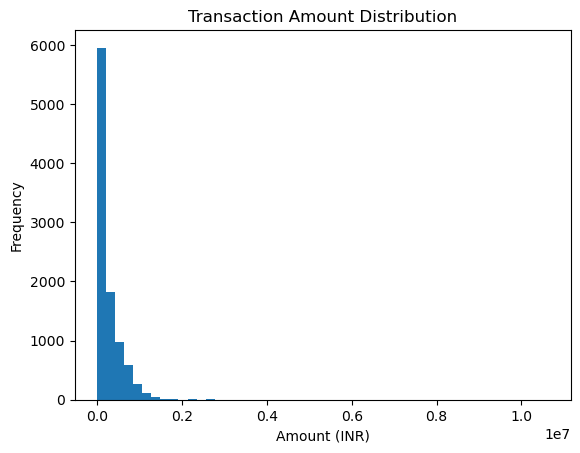

In [32]:
df["Amount"].plot(kind="hist", bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()

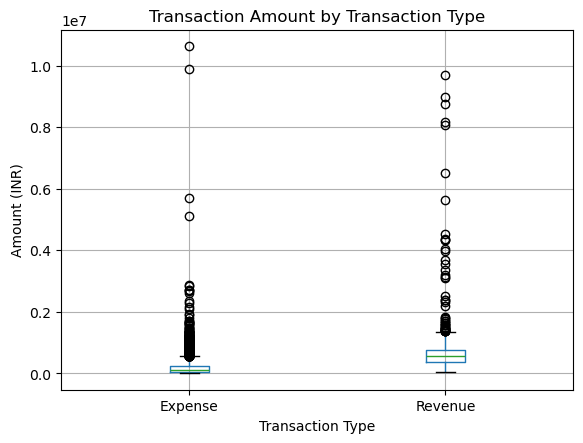

In [33]:
df.boxplot(column="Amount", by="Transaction_Type")

plt.title("Transaction Amount by Transaction Type")
plt.suptitle("")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (INR)")
plt.show()

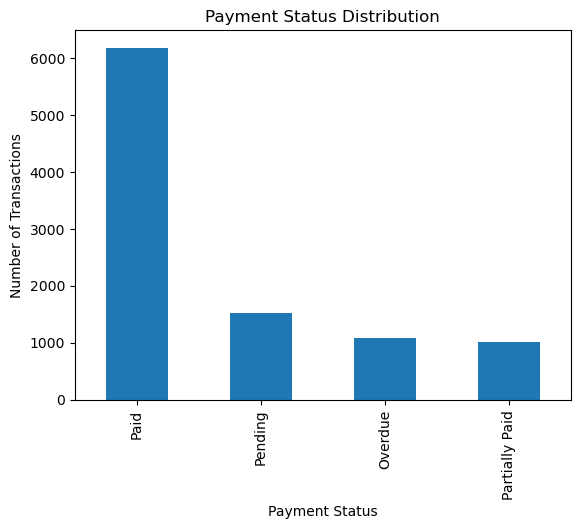

In [34]:
df["Payment_Status"].value_counts().plot(kind="bar")

plt.title("Payment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")
plt.show()

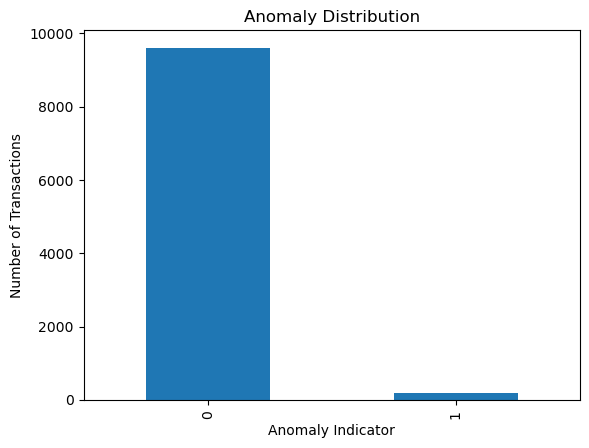

In [35]:
df["Anomaly_Indicator"].value_counts().plot(kind="bar")

plt.title("Anomaly Distribution")
plt.xlabel("Anomaly Indicator")
plt.ylabel("Number of Transactions")
plt.show()